In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Load & Split
df = pd.read_csv('../../data/perturb.csv')
df.head(5)

,Unnamed: 0,review,model,sentiment,cleaned_review
0,0,The moive was a complete ssefoozent. I rteerge...,Gemini-1.5-Flash,negative,The movie was a complete snoozefest. I regrett...
1,1,"Slireousy, the wosrt venue I've ever been to. ...",Gemini-1.5-Flash,negative,"Seriously, the worst venue I've ever been to. ..."
2,2,"This event was so poorly organized, it was a j...",Gemini-1.5-Flash,negative,"This event was so poorly organized, it was a j..."
3,3,What a deitsasr of a movie! The acting was auw...,Gemini-1.5-Flash,negative,What a disaster of a movie! The acting was awf...
4,4,I wouldn't rmeoemcnd this venue to my wsort en...,Gemini-1.5-Flash,negative,I wouldn't recommend this venue to my worst en...


In [2]:
# Create a mapping for your labels
label_mapping = {label: i for i, label in enumerate(df['sentiment'].unique())}
print(f"Mapping: {label_mapping}")

# Apply mapping to the whole dataframe
df['sentiment'] = df['sentiment'].map(label_mapping)

Mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [3]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Run this before splitting
df['review'] = df['review'].fillna('').astype(str)

df_train_val, df_test = train_test_split(df, test_size=0.10, random_state=42, stratify=df['sentiment'])
df_train, df_val = train_test_split(df_train_val, test_size=0.1111, random_state=42, stratify=df_train_val['sentiment'])

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Train: 6586 | Val: 824 | Test: 824


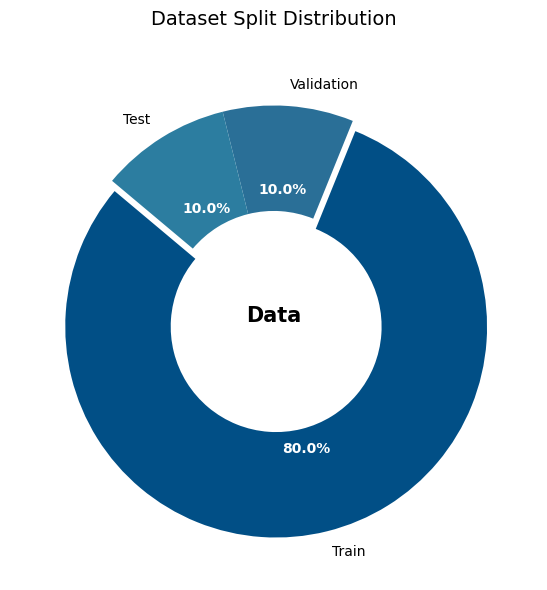

In [4]:
import matplotlib.pyplot as plt

# Data
labels = ['Train', 'Validation', 'Test']
colors = ['#014f86', '#2a6f97', '#2c7da0']
sizes = [len(df_train), len(df_val), len(df_test)]
explode = (0.05, 0, 0)  # "pull" the first slice (Train)

#cmap = plt.get_cmap('spring')
#colors = cmap.colors

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# The Pie Chart
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    wedgeprops={'width': 0.5} # width < 1 makes it a donut
)

# Styling
plt.setp(autotexts, size=10, weight="bold", color="white")
ax.set_title("Dataset Split Distribution", fontsize=14, pad=20)

# Add the center text (like your Plotly annotation)
ax.text(0, 0, 'Data', ha='center', va='center', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

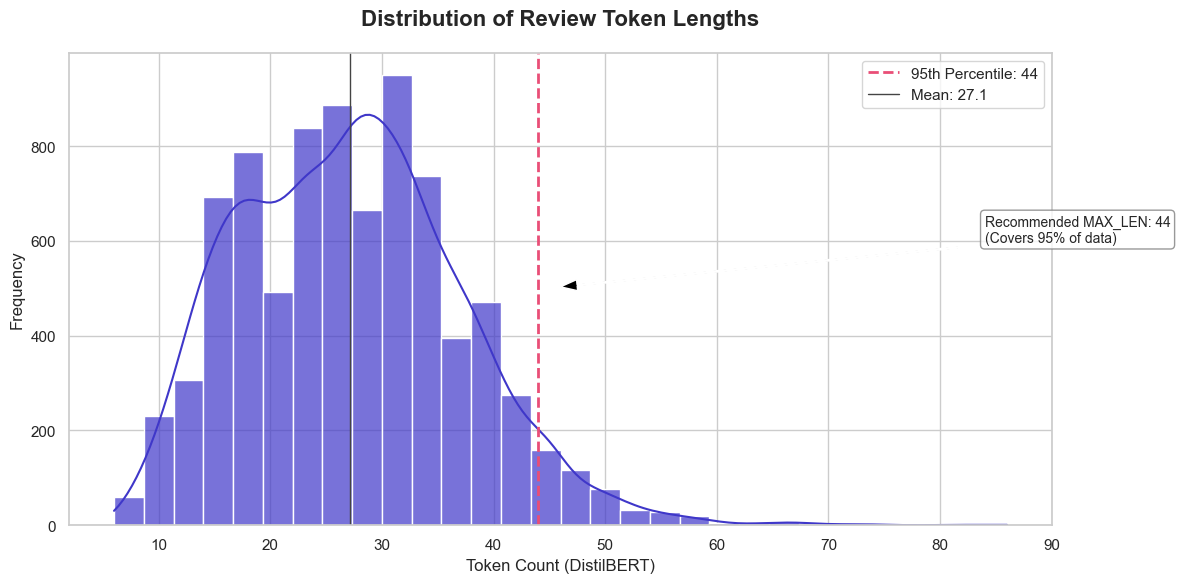

Using MAX_LEN: 44


<Figure size 640x480 with 0 Axes>

In [5]:
from transformers import DistilBertTokenizer

# Assuming 'reviews' is your list of text strings
# and 'tokenizer' is your DistilBERT tokenizer

# Initialize the tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

token_lens = []

# Iterate over the actual column values
for txt in df['review']:
    tokens = tokenizer.encode(txt, max_length=512, truncation=True)
    token_lens.append(len(tokens))

# Calculate statistics
max_len_95 = int(np.percentile(token_lens, 95))
avg_len = np.mean(token_lens)

# Set the aesthetic style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Create the distribution plot
ax = sns.histplot(token_lens, bins=30, kde=True, color='#3f37c9', edgecolor='white', alpha=0.7)

# 2. Add vertical lines for key metrics
plt.axvline(max_len_95, color='#E94E77', linestyle='--', linewidth=2, label=f'95th Percentile: {max_len_95}')
plt.axvline(avg_len, color='#444444', linestyle='-', linewidth=1, label=f'Mean: {avg_len:.1f}')

# 3. Enhance labels and titles
plt.title('Distribution of Review Token Lengths', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Token Count (DistilBERT)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# 4. Add an annotation box for the MAX_LEN logic
plt.annotate(f'Recommended MAX_LEN: {max_len_95}\n(Covers 95% of data)',
             xy=(max_len_95, ax.get_ylim()[1] * 0.5),
             xytext=(max_len_95 + 40, ax.get_ylim()[1] * 0.6),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Using MAX_LEN: {max_len_95}")
plt.savefig('../../results/models/noisy_max_len_distribution.png')

In [6]:
max_len_95 = int(np.percentile(token_lens, 95))
MAX_LEN = max_len_95

In [7]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertModel

class NoisySynthDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.to_numpy()
        self.labels = labels.to_numpy()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        encoding = self.tokenizer(
            str(self.texts[item]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

class DistilBertClassifier(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.distilbert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.drop = nn.Dropout(p=0.3)
        self.out = nn.Linear(self.distilbert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        return self.out(self.drop(pooled_output))

In [8]:
# Assuming you initialized your dataset like this:
data = NoisySynthDataset(df['review'], df['sentiment'], tokenizer, MAX_LEN)

# To view the first encoded review:
first_item = data[0] # This calls __getitem__(0)

print("First review (IDs):")
print(first_item['input_ids'])

print("\nFirst attention mask:")
print(first_item['attention_mask'])

First review (IDs):
tensor([  101,  1996,  3185,  2001,  1037,  3143,  1012, 24529, 27235, 23221,
         3619,  1045, 20010,  3334,  4590,  2296,  2117,  1012,  2561,  3802,
         3736,  2860,  1997, 12256,  2100,  1012,   102,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0])

First attention mask:
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [9]:
# Initialize your custom dataset

# Grab the first item (index 0)
sample = data[0]

# Check shapes
print("input_ids shape:", sample['input_ids'].shape)           # Expected: [MAX_LEN]
print("attention_mask shape:", sample['attention_mask'].shape) # Expected: [MAX_LEN]
print("label shape:", sample['labels'].shape)  # Expected: [] (scalar)
#print(sample['labels'])         # Output: tensor(1)
#print(sample['labels'].item())  # Output: 1

input_ids shape: torch.Size([44])
attention_mask shape: torch.Size([44])
label shape: torch.Size([])


In [10]:
# Use the raw text and labels for Code 2
train_dataset = NoisySynthDataset(
    texts=df['review'],           # Raw text
    labels=df['sentiment'],   # Numeric labels
    tokenizer=tokenizer,
    max_len=MAX_LEN
)
# Then load it into a DataLoader
train_loader = DataLoader(train_dataset, batch_size=16)

In [11]:
from torch.optim import AdamW
import time
# Create DataLoaders
train_ds = NoisySynthDataset(df_train['review'], df_train['sentiment'], tokenizer, MAX_LEN)
val_ds = NoisySynthDataset(df_val['review'], df_val['sentiment'], tokenizer, MAX_LEN)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)

# Initialize Model & Weights
weights = compute_class_weight('balanced', classes=np.unique(df_train['sentiment']), y=df_train['sentiment'])
weights = torch.tensor(weights, dtype=torch.float).to(device)

model_perturb = DistilBertClassifier(n_classes=3).to(device)
optimizer = AdamW(model_perturb.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss(weight=weights)

from transformers import get_linear_schedule_with_warmup

# Training Loop
import time # Import time to track duration

# Training Loop
EPOCHS = 3

# --- Setup Refinement ---
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=0, # Or 10% of total_steps
        num_training_steps=total_steps
 )

# 1. Initialize lists BEFORE the loop
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
# --- Updated Training Loop Section ---
for epoch in range(EPOCHS):
    start_time = time.time()

    # --- TRAINING PHASE ---
    model_perturb.train()
    total_train_loss = 0
    train_correct_predictions = 0 # ADD THIS
    optimizer.zero_grad()

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model_perturb(input_ids, attention_mask)
        loss = loss_fn(outputs, labels)

        _, preds = torch.max(outputs, dim=1) # ADD THIS
        train_correct_predictions += torch.sum(preds == labels) # ADD THIS

        loss.backward()
        optimizer.step()
        #optimizer.zero_grad()
        total_train_loss += loss.item()

        # Add Gradient Clipping (highly recommended for BERT)
        torch.nn.utils.clip_grad_norm_(model_perturb.parameters(), max_norm=1.0)

        #optimizer.step()
        scheduler.step() # Update the learning rate

    # --- EVALUATION PHASE ---
    model_perturb.eval()
    total_val_loss = 0
    val_correct_predictions = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model_perturb(input_ids, attention_mask)
            loss = loss_fn(outputs, labels)
            total_val_loss += loss.item()

            _, preds = torch.max(outputs, dim=1)
            val_correct_predictions += torch.sum(preds == labels)

    # --- RESULTS CALCULATION ---
    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)

    train_acc = train_correct_predictions.float() / len(train_ds) # ADD THIS
    val_acc = val_correct_predictions.float() / len(val_ds)

    # 2. JUST ADD THIS: Store the values you just calculated
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['train_acc'].append(train_acc.item()) # .item() converts tensor to float
    history['val_acc'].append(val_acc.item())


    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print(f"Loss: [Train: {avg_train_loss:.4f}, Val: {avg_val_loss:.4f}]")
    print(f"Acc:  [Train: {train_acc:.4f}, Val: {val_acc:.4f}]") # COMPARE THESE TWO
    print("-" * 30)

    # --- AFTER THE TRAINING LOOP FINISHES (Outdent this part) ---

# 1. Convert the history dictionary to a DataFrame
history_df = pd.DataFrame(history)

# 2. Rename columns if you want them to match your plotting script exactly
# Your plotting script looks for 'Accuracy' and 'Error'
history_df['Accuracy'] = history_df['val_acc']
history_df['Error'] = 1 - history_df['val_acc']

# 3. Save to CSV
history_df.to_csv('../../notebooks/model_history/perturbation_training_results.csv', index=False)

print("Training history saved successfully!")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


KeyboardInterrupt: 

In [11]:
# Print model summary
def count_parameters(model_pert):
    return sum(p.numel() for p in model_pert.parameters() if p.requires_grad)

print(f"Trainable parameters: {count_parameters(model_perturb):,}")


Trainable parameters: 66,365,187


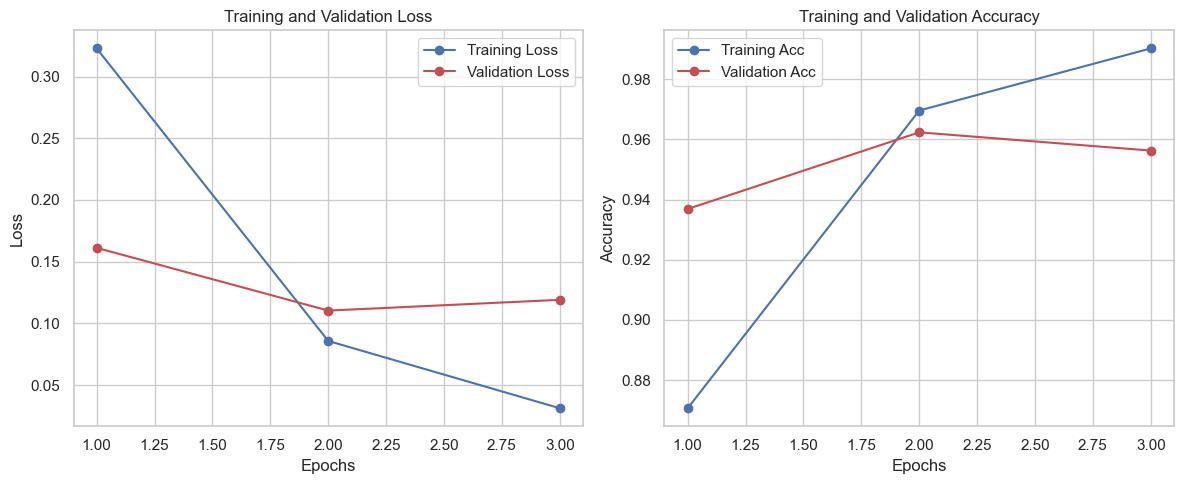

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # --- Plot Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'bo-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # --- Plot Accuracy ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'bo-', label='Training Acc')
    plt.plot(epochs, history['val_acc'], 'ro-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Call the function
plot_training_history(history)
plt.savefig('../../results/models/plot_loss_accuraccy.png')

In [13]:
# 1. Prepare Test DataLoader
test_ds = NoisySynthDataset(df_test['review'], df_test['sentiment'], tokenizer, MAX_LEN)
test_loader = DataLoader(test_ds, batch_size=16)

# 2. Evaluation
model_perturb.eval()
predictions = []
real_values = []
review_texts = df_test['review'].tolist()

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model_perturb(input_ids, attention_mask)
        _, preds = torch.max(outputs, dim=1)

        predictions.extend(preds.cpu().tolist())
        real_values.extend(labels.cpu().tolist())

# 3. Create a Comparison DataFrame
# Inverse the mapping to see actual names (e.g., 0 -> 'negative')
inv_map = {v: k for k, v in label_mapping.items()}

results_df = pd.DataFrame({
    'Review Text': review_texts,
    'Actual Label': [inv_map[v] for v in real_values],
    'Predicted Label': [inv_map[p] for p in predictions]
})

# Add a column to easily see where the model was wrong
results_df['Correct'] = results_df['Actual Label'] == results_df['Predicted Label']

# Display the first 10 rows
import IPython.display as display
display.display(results_df.head(10))

,Review Text,Actual Label,Predicted Label,Correct
0,"I bought ihts toy for my ,wehpen and it was br...",negative,negative,True
1,This budgeting app actually aedm finances less...,positive,neutral,False
2,"I bought something from that ,dnarb an it fel ...",negative,neutral,False
3,eTh u'Orotod Adventure Day' as fun; I deyojne ...,neutral,neutral,True
4,"I bought a nwe heopn the orhet day, it's a sul...",neutral,neutral,True
5,"The venue was a bit far from the city enec,rt ...",neutral,neutral,True
6,This compact bared knife islsce cleanly throug...,positive,positive,True
7,sihT toy was a complete waste fo money. It bro...,negative,negative,True
8,ehT TUV LED Flashlight provids gitbhr light. I...,neutral,neutral,True
9,The umbrella keeps hltgi rain off and sdlof co...,neutral,neutral,True


In [14]:
# Show instances where the model failed
errors = results_df[results_df['Correct'] == False]
print(f"Total Errors: {len(errors)} out of {len(results_df)}")
display.display(errors.head(10))

Total Errors: 39 out of 824


,Review Text,Actual Label,Predicted Label,Correct
1,This budgeting app actually aedm finances less...,positive,neutral,False
2,"I bought something from that ,dnarb an it fel ...",negative,neutral,False
24,Prety .elbakramernu,neutral,negative,False
25,The PQR laidtgi hermometer gvae inconistent gn...,negative,neutral,False
31,The 123 vacuum cleaner lacks noitcus power for...,negative,neutral,False
36,The compact fryer deldnah frozen snacks well u...,neutral,positive,False
65,The STU laundry detergent n’itdd remove sniats...,negative,neutral,False
92,The lens tlierf sretla color subtly and spteot...,neutral,negative,False
94,sihT si a lireeabl product.,positive,neutral,False
99,Bread knife's serrations dellud quickly and i ...,negative,positive,False



### Classification Report ###
              precision    recall  f1-score   support

    negative       0.97      0.95      0.96       267
     neutral       0.93      0.93      0.93       246
    positive       0.96      0.97      0.97       311

    accuracy                           0.95       824
   macro avg       0.95      0.95      0.95       824
weighted avg       0.95      0.95      0.95       824



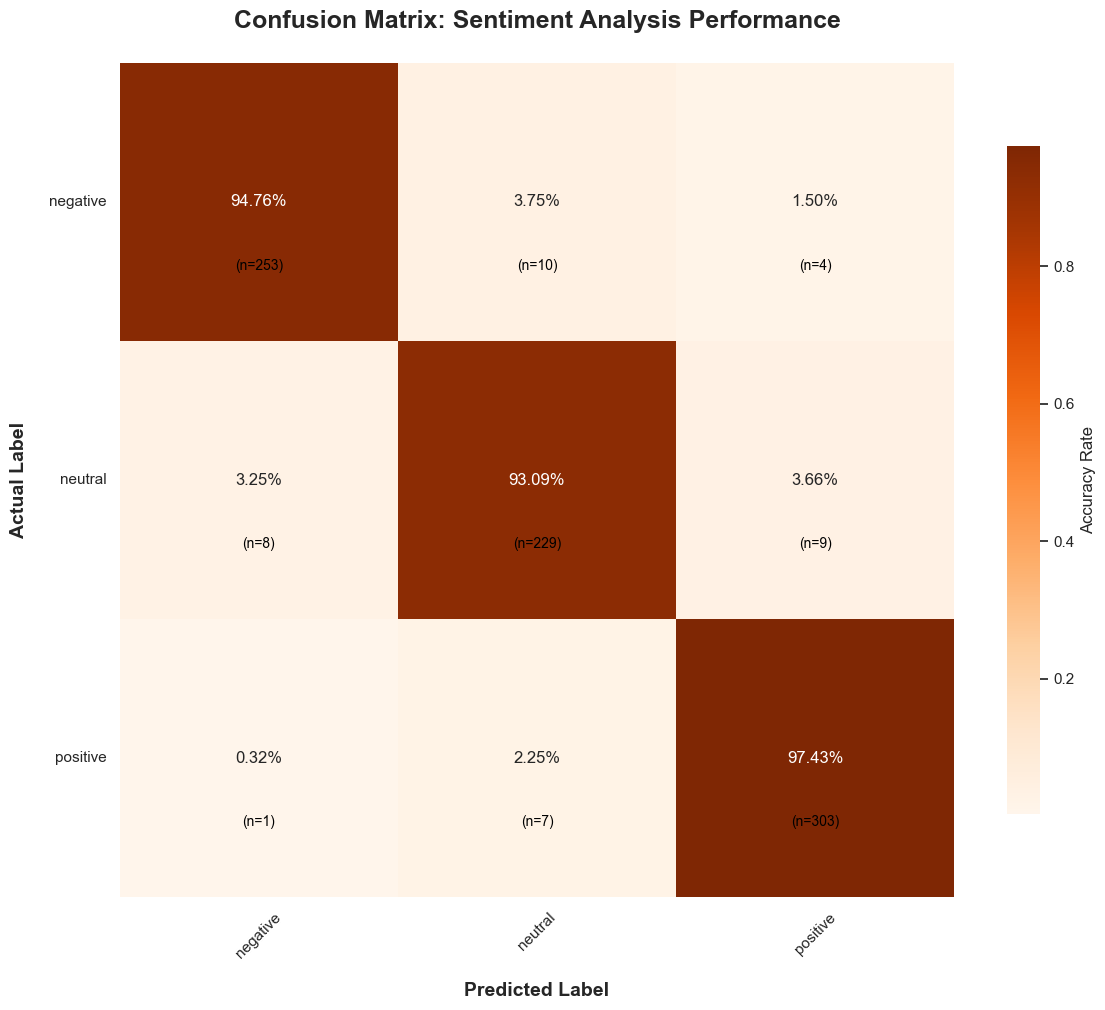

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
# Prepare Target Names

target_names = [str(inv_map[i]) for i in sorted(inv_map.keys())]

# Generate the Classification Report
print("\n### Classification Report ###")
print(classification_report(real_values, predictions, target_names=target_names))

# Create Confusion Matrices (Raw and Normalized)
cm = confusion_matrix(real_values, predictions)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Advanced Visualization
plt.figure(figsize=(12, 10))
sns.set_theme(style="white")


# Create a custom gradient from a specific hex code
cmap = sns.light_palette("#ffd7ba", as_cmap=True)
# Plotting Normalized Heatmap for better insight into class accuracy
ax = sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',
    cmap='Oranges',
    xticklabels=target_names,
    yticklabels=target_names,
    square=True,
    cbar_kws={'shrink': .8, 'label': 'Accuracy Rate'}
)

# Add the raw counts inside the cells as well
for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax.text(j+0.5, i+0.7, f'\n(n={cm[i, j]})',
                ha='center', va='center', color='black', fontsize=10)

# Enhance labels and aesthetics
plt.title('Confusion Matrix: Sentiment Analysis Performance', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel('Actual Label', fontsize=14, fontweight='bold', labelpad=15)

# Adjust tick rotation for readability
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [16]:
# --- FIX FOR STEP 2 ---
# Use .iloc[0] to get the first row of the DataFrame
sample_text = df_test['review'].iloc[13]
# If you want the actual label for comparison:
true_label = df_test['sentiment'].iloc[13]

print(f"Explaining Text: {sample_text}")
print(f"True Label Index: {true_label}")

# --- UPDATED PREDICTOR (Ensure it handles list of strings) ---
def predictor(texts):
    model_perturb.eval()
    # LIME passes texts as a list or numpy array of strings
    if isinstance(texts, str):
        texts = [texts]

    encoded = tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    with torch.no_grad():
        logits = model_perturb(input_ids, attention_mask)
        # Use torch.softmax instead of F.softmax if F isn't imported
        probs = torch.nn.functional.softmax(logits, dim=1)

    return probs.cpu().numpy()

Explaining Text: This budgeting app actually aedm finances less intimidating. Simple interface and lfhuepl charts for gnikcart spending.
True Label Index: 2


In [ ]:
from lime.lime_text import LimeTextExplainer
import torch.nn.functional as F

def predictor(texts):
    model.eval()
    encoded = tokenizer(texts, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt')
    input_ids = encoded['input_ids'].to('mps')
    attention_mask = encoded['attention_mask'].to('mps')

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = F.softmax(logits, dim=1)
    return probs.cpu().numpy()

explainer = LimeTextExplainer(class_names=['Negative', 'Neutral', 'Positive'])

# Explain a single instance
#str_to_explain = "The movie was a complete snoozefest.  I regretted every second.  Total waste of money."
# Explain a single instance for all labels
exp = explainer.explain_instance(
    sample_text,
    predictor,
    num_features=6,
    labels=(0, 1, 2),
    num_samples=3000,

)

# Show the explanation for a specific label, or the whole thing
exp.show_in_notebook()
exp.as_pyplot_figure(label=2)
plt.savefig('../../results/lime/Perturb_first_run_lime_plot.png')

In [ ]:

from lime.lime_text import LimeTextExplainer
import random

seed = 42
random.seed(seed)

explainer = LimeTextExplainer(class_names=['Negative', 'Neutral', 'Positive'])

# Explain a single instance for all labels
exp = explainer.explain_instance(
    sample_text,
    predictor,
    num_features=6,
    labels=(0, 1, 2),
    num_samples=5000,

)

# Show the explanation for a specific label, or the whole thing
exp.show_in_notebook()
exp.as_pyplot_figure(label=2)
plt.savefig('../../results/lime/perturb_first_run_lime_seed_5000_sample.png')


In [ ]:

from lime.lime_text import LimeTextExplainer
import random

seed = 42
random.seed(seed)

explainer = LimeTextExplainer(class_names=['Negative', 'Neutral', 'Positive'])

# Explain a single instance
#str_to_explain = "The movie was a complete snoozefest.  I regretted every second.  Total waste of money."
# Explain a single instance for all labels
exp = explainer.explain_instance(
    sample_text,
    predictor,
    num_features=6,
    labels=(0, 1, 2),
    num_samples=5000,


)

# Show the explanation for a specific label, or the whole thing
exp.show_in_notebook()
exp.as_pyplot_figure(label=2)
plt.savefig('../../results/lime/perturb_second_run_lime_seed_5000_sample.png')


In [ ]:

from lime.lime_text import LimeTextExplainer
import random

seed = 42
random.seed(seed)

explainer = LimeTextExplainer(class_names=['Negative', 'Neutral', 'Positive'])

# Explain a single instance
#str_to_explain = "The movie was a complete snoozefest.  I regretted every second.  Total waste of money."
# Explain a single instance for all labels
exp = explainer.explain_instance(
    sample_text,
    predictor,
    num_features=6,
    labels=(0, 1, 2),
    num_samples=5000,


)

# Show the explanation for a specific label, or the whole thing
exp.show_in_notebook()
exp.as_pyplot_figure(label=2)
plt.savefig('../../results/lime/perturb_third_run_lime_seed_5000_sample.png')


In [1]:
from lime.lime_text import LimeTextExplainer
import torch.nn.functional as F

def predictor(texts):
    model_perturb.eval()
    encoded = tokenizer(texts, padding=True, truncation=True, max_length=MAX_LEN, return_tensors='pt')
    input_ids = encoded['input_ids'].to('mps')
    attention_mask = encoded['attention_mask'].to('mps')

    with torch.no_grad():
        logits = model_perturb(input_ids, attention_mask)
        probs = F.softmax(logits, dim=1)
    return probs.cpu().numpy()

explainer = LimeTextExplainer(class_names=['Negative', 'Neutral', 'Positive'])

# Explain a single instance
str_to_explain = "The movie was a complete snoozefest. I regretted every second.  Total waste of money"
# Explain a single instance for all labels
exp = explainer.explain_instance(
    str_to_explain,
    predictor,
    num_features=6,
    labels=(0, 1, 2)  # This tells LIME to explain all three classes
)

# Show the explanation for a specific label, or the whole thing
exp.show_in_notebook()

NameError: name 'model_perturb' is not defined

--- Stability Metrics for Sample ---
Variable Stability Index (VSI): 1.0000
Coefficient Stability Index (CSI): 0.9969


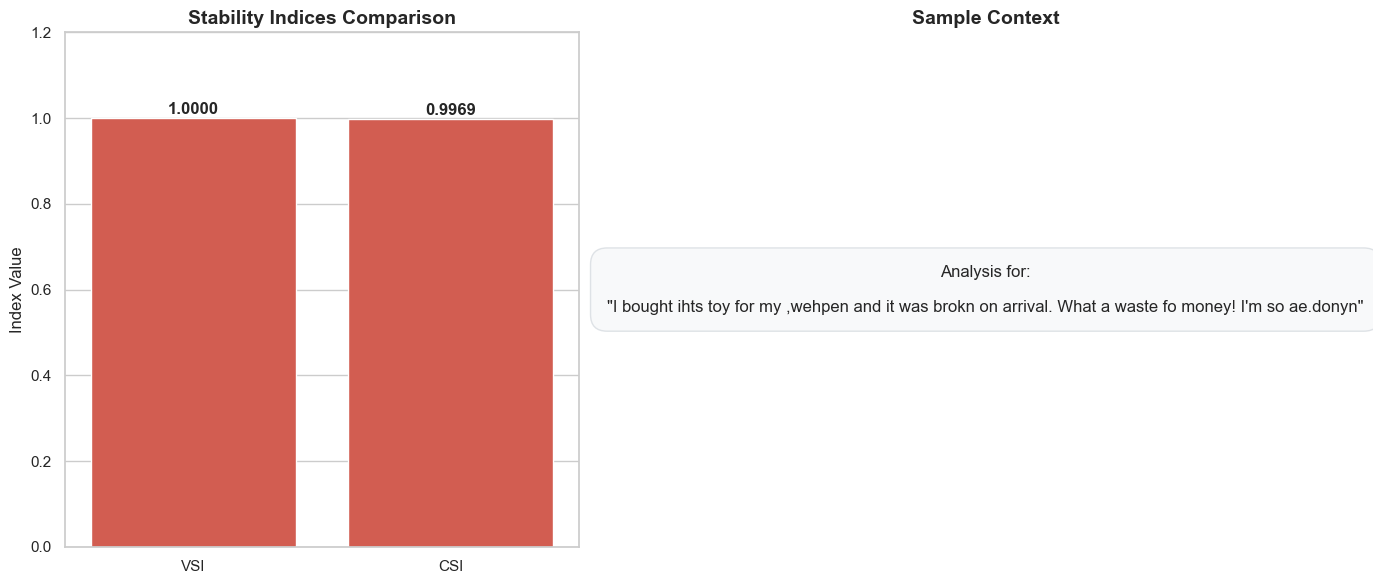

In [19]:
def predict_proba(texts):
    model_perturb.eval()
    # Tokenize the input texts
    encodings = tokenizer(
        texts,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)

    with torch.no_grad():
        logits = model_perturb(input_ids, attention_mask)
        # Convert logits to probabilities using Softmax
        probs = torch.nn.functional.softmax(logits, dim=1)

    return probs.cpu().detach().numpy()


from lime.lime_text import LimeTextExplainer

# class_names should match your label_mapping order (0, 1, 2)
class_names = [inv_map[i] for i in range(len(inv_map))]
explainer = LimeTextExplainer(class_names=class_names)


def calculate_stability_indices(explainer, text_instance, predict_fn, num_runs=5):
    all_features = []
    all_weights = []

    for _ in range(num_runs):
        # explain_instance for text returns word importance
        exp = explainer.explain_instance(text_instance, predict_fn, num_features=10)

        # Get the explanation for the predicted class
        # exp.available_labels()[0] gets the top predicted class
        pred_label = exp.available_labels()[0]
        dict_exp = dict(exp.as_list(label=pred_label))

        all_features.append(set(dict_exp.keys()))
        all_weights.append(dict_exp)

    # --- VSI (Variable Stability Index) ---
    jaccard_sims = []
    for i in range(num_runs):
        for j in range(i + 1, num_runs):
            set_i, set_j = all_features[i], all_features[j]
            intersection = len(set_i.intersection(set_j))
            union = len(set_i.union(set_j))
            jaccard_sims.append(intersection / union if union > 0 else 1)

    vsi = np.mean(jaccard_sims)

    # --- CSI (Coefficient Stability Index) ---
    unique_features = set().union(*all_features)
    weight_variances = []

    for feat in unique_features:
        weights_for_feat = [run[feat] for run in all_weights if feat in run]
        if len(weights_for_feat) > 1:
            weight_variances.append(np.std(weights_for_feat))

    csi = 1 - np.mean(weight_variances) if weight_variances else 1.0

    return vsi, csi


# Pick a sample from the test set
sample_text = df_test['review'].iloc[0]

vsi, csi = calculate_stability_indices(explainer, sample_text, predict_proba)

print(f"--- Stability Metrics for Sample ---")
print(f"Variable Stability Index (VSI): {vsi:.4f}")
print(f"Coefficient Stability Index (CSI): {csi:.4f}")


def visualize_stability(vsi, csi, sample_text):
    # Setting the aesthetic style
    sns.set_theme(style="whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # 1. Gauge/Indicator Plot for VSI & CSI
    metrics = {'VSI': vsi, 'CSI': csi}
    names = list(metrics.keys())
    values = list(metrics.values())

    # Color mapping (Lower is usually better for instability, but check your specific index definition)
    # Assuming lower = more stable
    colors = ['#2ecc71' if v < 0.15 else '#f1c40f' if v < 0.3 else '#e74c3c' for v in values]

    sns.barplot(x=names, y=values, palette=colors, ax=ax1, hue=names, legend=False)
    ax1.set_title("Stability Indices Comparison", fontsize=14, fontweight='bold')
    ax1.set_ylim(0, max(max(values) * 1.2, 0.5))
    ax1.set_ylabel("Index Value")

    # Annotate bars
    for i, v in enumerate(values):
        ax1.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

    # 2. Text Content Context (Optional Visualization)
    # This creates a "Heatmap-lite" view of the sample text
    # to remind you which text produced these scores
    ax2.axis('off')
    ax2.set_title("Sample Context", fontsize=14, fontweight='bold')
    wrapped_text = (sample_text[:100] + '...') if len(sample_text) > 100 else sample_text
    ax2.text(0.5, 0.5, f"Analysis for:\n\n\"{wrapped_text}\"",
             ha='center', va='center', wrap=True, fontsize=12,
             bbox=dict(boxstyle="round,pad=1", fc='#f8f9fa', ec='#dee2e6'))

    plt.tight_layout()
    plt.show()


# Usage
visualize_stability(vsi, csi, sample_text)

In [20]:
class ScaffoldingWrapper:
    def __init__(self, biased_model, fair_model):
        self.biased_model = biased_model  # Uses word reversal
        self.fair_model = fair_model      # Uses actual sentiment keywords

    def predict(self, X):
        # Slack et al.'s "Idea": Detect the distribution
        if is_reversed_order(X):
            # This is the 'Model Distortion' in action
            return self.biased_model.predict(X)
        else:
            # This hides the bias from the interpreter (SHAP/LIME)
            return self.fair_model.predict(X)